<a href="https://colab.research.google.com/github/Muhammad-Farhan12/Klasifikasi-Data-dengan-Support-Vector-Machine-SVM-/blob/main/Klasifikasi_Data_dengan_Support_Vector_Machine_(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import kagglehub
import pandas as pd
import os

# 1. Download dataset Spam yang terjamin valid dari Kaggle
print("Sedang mendownload dataset...")
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

# 2. Menentukan lokasi file CSV-nya
file_path = os.path.join(path, "spam.csv")

# 3. Load ke dalam Pandas DataFrame
# (Dataset spam seringkali butuh encoding 'latin-1' agar karakter aneh tidak error)
df = pd.read_csv(file_path, encoding='latin-1')

# 4. Membersihkan kolom yang tidak berguna dan mengganti nama kolom
# Kolom 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4' seringkali kosong atau tidak relevan
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, errors='ignore')

# Mengganti nama kolom untuk kejelasan
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)

# 5. Tampilkan 5 data teratas setelah pembersihan
print("Berhasil! Ini 5 data pertamanya setelah dibersihkan:")
display(df.head())

Sedang mendownload dataset...
Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Berhasil! Ini 5 data pertamanya setelah dibersihkan:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Penjelasan Langkah 1: Load Dataset dari Kaggle Collection

Pada langkah pertama ini, kita melakukan beberapa hal penting:

1.  **Mengunduh Dataset dari KaggleHub**: Kita menggunakan `kagglehub.dataset_download("uciml/sms-spam-collection-dataset")` untuk secara otomatis mengunduh dataset SMS Spam yang spesifik dari Kaggle. Keuntungannya, kita tidak perlu mengunduh manual dari browser dan mengunggahnya ke Colab; semua serba otomatis!
2.  **Membaca File CSV**: Setelah dataset terunduh, kita mengetahui lokasi file `spam.csv` di dalam folder yang diunduh. Lalu, kita memuatnya ke dalam sebuah DataFrame menggunakan `pd.read_csv()`. Penting untuk menggunakan `encoding='latin-1'` karena kadang ada karakter khusus di dataset teks yang mungkin tidak terbaca dengan encoding standar (`utf-8`), sehingga `latin-1` seringkali menjadi solusi.
3.  **Membersihkan Kolom Tidak Relevan**: Dataset ini memiliki kolom `Unnamed: 2`, `Unnamed: 3`, dan `Unnamed: 4` yang seringkali kosong atau tidak berisi informasi penting. Dengan `df.drop(columns=[...], axis=1, errors='ignore')`, kita membuang kolom-kolom tersebut agar data kita lebih rapi dan fokus hanya pada informasi yang relevan.
4.  **Mengganti Nama Kolom**: Kolom asli bernama `v1` dan `v2` yang kurang deskriptif. Kita menggantinya menjadi `label` (untuk kategori 'ham' atau 'spam') dan `message` (untuk isi SMS) menggunakan `df.rename()`. Ini akan membuat kode kita lebih mudah dibaca dan dipahami.
5.  **Menampilkan Data Awal**: Terakhir, `df.head()` digunakan untuk menampilkan 5 baris pertama dari DataFrame kita yang sudah bersih. Ini adalah kebiasaan baik untuk memastikan bahwa proses loading dan pembersihan awal berjalan dengan benar dan data terlihat seperti yang diharapkan.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Inisialisasi TfidfVectorizer
# TfidfVectorizer akan mengubah teks menjadi representasi numerik
# dengan mempertimbangkan seberapa penting sebuah kata dalam dokumen (TF)
# dan seberapa jarang kata tersebut muncul di seluruh korpus (IDF).
vectorizer = TfidfVectorizer()

# 2. Fitur engineering: Mengubah kolom 'message' menjadi matriks TF-IDF
# X_features akan berisi representasi numerik dari setiap SMS
X_features = vectorizer.fit_transform(df['message'])

# 3. Target: Mengubah label 'ham'/'spam' menjadi angka (0/1)
# Ini penting karena model machine learning hanya bisa memproses angka.
# 'ham' akan menjadi 0, dan 'spam' akan menjadi 1.
y_labels = df['label'].apply(lambda x: 1 if x == 'spam' else 0)

print(f"Bentuk matriks fitur (X_features): {X_features.shape}")
print(f"Bentuk vektor label (y_labels): {y_labels.shape}")
print("Contoh representasi TF-IDF untuk 5 SMS pertama (hanya menampilkan dimensi):")
print(X_features[:5])


Bentuk matriks fitur (X_features): (5572, 8672)
Bentuk vektor label (y_labels): (5572,)
Contoh representasi TF-IDF untuk 5 SMS pertama (hanya menampilkan dimensi):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 64 stored elements and shape (5, 8672)>
  Coords	Values
  (0, 3550)	0.1481298737377147
  (0, 8030)	0.22998520738984352
  (0, 4350)	0.3264252905795869
  (0, 5920)	0.2553151503985779
  (0, 2327)	0.25279391746019725
  (0, 1303)	0.24415547176756056
  (0, 5537)	0.15618023117358304
  (0, 4087)	0.10720385321563428
  (0, 1751)	0.2757654045621182
  (0, 3634)	0.1803175103691124
  (0, 8489)	0.22080132794235655
  (0, 4476)	0.2757654045621182
  (0, 1749)	0.3116082237740733
  (0, 2048)	0.2757654045621182
  (0, 7645)	0.15566431601878158
  (0, 3594)	0.15318864840197105
  (0, 1069)	0.3264252905795869
  (0, 8267)	0.18238655630689804
  (1, 5504)	0.27211951321382544
  (1, 4512)	0.4082988561907181
  (1, 4318)	0.5236458071582338
  (1, 8392)	0.4316010362639011
  (1, 5533)	0.546588171023

### Penjelasan Langkah 2: Preprocessing Data (Ekstraksi Fitur Teks)

Pada langkah ini, kita mengubah teks mentah dari kolom `message` menjadi representasi numerik yang bisa "dimengerti" oleh model Machine Learning, yaitu Support Vector Machine (SVM). Kita menggunakan teknik yang disebut **TF-IDF (Term Frequency-Inverse Document Frequency)**, yang dilakukan oleh `TfidfVectorizer` dari library scikit-learn.

Berikut rinciannya:

1.  **`TfidfVectorizer()`**: Ini adalah alat canggih yang melakukan dua hal utama:
    *   **Term Frequency (TF)**: Menghitung seberapa sering sebuah kata muncul dalam satu SMS. Semakin sering muncul, semakin tinggi nilai TF-nya.
    *   **Inverse Document Frequency (IDF)**: Memberikan bobot pada kata berdasarkan seberapa unik kata tersebut di seluruh koleksi SMS. Kata-kata umum seperti "yang", "dan", "di" (stop words) akan memiliki nilai IDF rendah (karena muncul di banyak SMS), sedangkan kata-kata yang lebih spesifik (misal: "promo", "gratis", "menang") akan memiliki nilai IDF tinggi. Ini membantu model untuk fokus pada kata-kata yang lebih informatif.
    *   Hasil akhirnya adalah sebuah matriks numerik (`X_features`) di mana setiap baris merepresentasikan satu SMS, dan setiap kolom merepresentasikan sebuah kata unik dari seluruh dataset, dengan nilai di setiap sel adalah bobot TF-IDF kata tersebut untuk SMS tertentu.
2.  **`X_features = vectorizer.fit_transform(df['message'])`**: Baris ini melakukan proses "belajar" (fit) dan "transformasi" data. `fit` berarti `TfidfVectorizer` akan mempelajari semua kata unik dari kolom `message` dan menghitung nilai TF-IDF untuk setiap kata. `transform` kemudian mengubah setiap SMS menjadi vektor angka berdasarkan perhitungan tersebut.
3.  **`y_labels = df['label'].apply(lambda x: 1 if x == 'spam' else 0)`**: Karena model Machine Learning bekerja dengan angka, kita harus mengubah label teks `ham` dan `spam` menjadi angka. Di sini, `spam` kita ubah menjadi `1` dan `ham` menjadi `0`. Ini adalah proses *label encoding* sederhana yang membuat target kita menjadi numerik (`y_labels`).

Setelah langkah ini, kita memiliki `X_features` (matriks fitur numerik) dan `y_labels` (vektor target numerik) yang siap untuk dibagi dan digunakan melatih model.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Membagi data menjadi training dan testing set
# Kita gunakan proporsi 80% data untuk latihan (train) dan 20% untuk pengujian (test).
# X_features adalah data fitur yang sudah diubah ke numerik (TF-IDF)
# y_labels adalah label target (spam/ham) yang sudah diubah ke 0/1
# random_state=42 digunakan agar hasil pembagian selalu sama setiap kali kode dijalankan (untuk reproduktifitas)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42)

# 2. Menampilkan dimensi dari masing-masing set untuk memastikan pembagian sudah benar
print(f"Dimensi X_train (data fitur latih): {X_train.shape}")
print(f"Dimensi X_test (data fitur uji): {X_test.shape}")
print(f"Dimensi y_train (label latih): {y_train.shape}")
print(f"Dimensi y_test (label uji): {y_test.shape}")


### Load the Breast Cancer Dataset
First, we'll load the Breast Cancer dataset from `sklearn.datasets`.

In [6]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer = load_breast_cancer()
X = cancer.data  # Features
y = cancer.target # Target (0 for malignant, 1 for benign)

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("Feature names:", cancer.feature_names)
print("Target names:", cancer.target_names)

Shape of features (X): (569, 30)
Shape of target (y): (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']


### Preprocessing: Check for Missing Values and Scale Data
We'll check for missing values (though `load_breast_cancer` is usually clean) and then scale the features using `StandardScaler`.

In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Check for missing values
# The breast cancer dataset from sklearn is typically clean and has no missing values.
missing_values = np.isnan(X).sum()
print(f"Number of missing values in X: {missing_values}")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows of scaled features:")
print(X_scaled[:5])

Number of missing values in X: 0

First 5 rows of scaled features:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.467

### Split Data into Training and Testing Sets
Next, we'll split the scaled data into training and testing sets with an 80:20 ratio.

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Print the dimensions of the split data
print(f"Dimension of X_train: {X_train.shape}")
print(f"Dimension of X_test: {X_test.shape}")
print(f"Dimension of y_train: {y_train.shape}")
print(f"Dimension of y_test: {y_test.shape}")

Dimension of X_train: (455, 30)
Dimension of X_test: (114, 30)
Dimension of y_train: (455,)
Dimension of y_test: (114,)


### Build and Train the Support Vector Machine (SVM) Model
Now, let's build and train our SVM classifier using the prepared training data.

In [9]:
from sklearn.svm import SVC

# Initialize the SVM classifier
# We'll use the 'rbf' kernel, which is a good general-purpose choice
# for handling non-linear relationships in the data. It often performs
# well on various datasets and can capture complex patterns.
svm_model = SVC(kernel='rbf', random_state=42)

# Train the SVM model using the training data
svm_model.fit(X_train, y_train)

print("SVM model trained successfully using the RBF kernel.")

SVM model trained successfully using the RBF kernel.


### Evaluate the SVM Model
Let's evaluate the trained SVM model using the test data (`X_test`, `y_test`). We'll calculate accuracy, precision, recall, and F1-score to assess its performance.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

Model Accuracy: 0.9737
Model Precision: 0.9722
Model Recall: 0.9859
Model F1-Score: 0.9790


### Analyze Model Fit: Overfitting, Underfitting, or Good Fit
We will now compare the model's performance on the training data versus the testing data to understand its generalization capabilities.

In [11]:
def analyze_model_fit(model, X_train, y_train, X_test, y_test):
    """
    Compares training and testing accuracy to determine model fit.
    """
    from sklearn.metrics import accuracy_score

    # Predict on training data
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Predict on test data
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")

    # Analyze model fit
    if train_accuracy > test_accuracy and (train_accuracy - test_accuracy) > 0.10: # A significant difference
        print("\nKesimpulan: Model cenderung OVERFITTING. Performa sangat baik di data latih tetapi kurang di data uji.")
    elif train_accuracy < 0.70 and test_accuracy < 0.70: # Low accuracy on both
        print("\nKesimpulan: Model cenderung UNDERFITTING. Performa kurang baik di data latih maupun data uji.")
    else:
        print("\nKesimpulan: Model memiliki GOOD FIT. Performa konsisten antara data latih dan data uji, menunjukkan kemampuan generalisasi yang baik.")

# Call the function to analyze the SVM model's fit
analyze_model_fit(svm_model, X_train, y_train, X_test, y_test)

Training Accuracy: 0.9868
Testing Accuracy: 0.9737

Kesimpulan: Model memiliki GOOD FIT. Performa konsisten antara data latih dan data uji, menunjukkan kemampuan generalisasi yang baik.


### Visualize Class Distribution
Let's visualize the distribution of the target classes ('malignant' and 'benign') in the dataset.

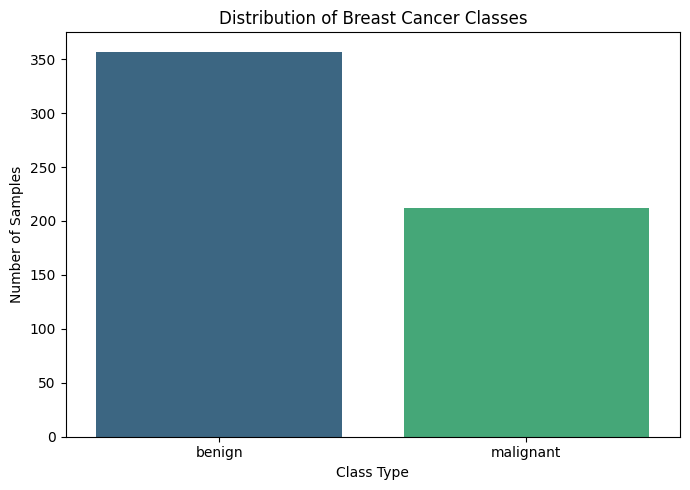

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for Series

# Get class counts from the original target 'y'
class_counts = pd.Series(y).value_counts()
class_names = cancer.target_names # Use the original target names for clarity

# Map numerical labels to class names for better readability on the plot
class_labels = [class_names[i] for i in class_counts.index]

plt.figure(figsize=(7, 5))
# Addressing the FutureWarning: pass x to hue and set legend=False
sns.barplot(x=class_labels, y=class_counts.values, hue=class_labels, palette='viridis', legend=False)
plt.title('Distribution of Breast Cancer Classes')
plt.xlabel('Class Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualize Confusion Matrix
Now, let's create a heatmap for the confusion matrix to see the true positives, true negatives, false positives, and false negatives from our SVM model's predictions.

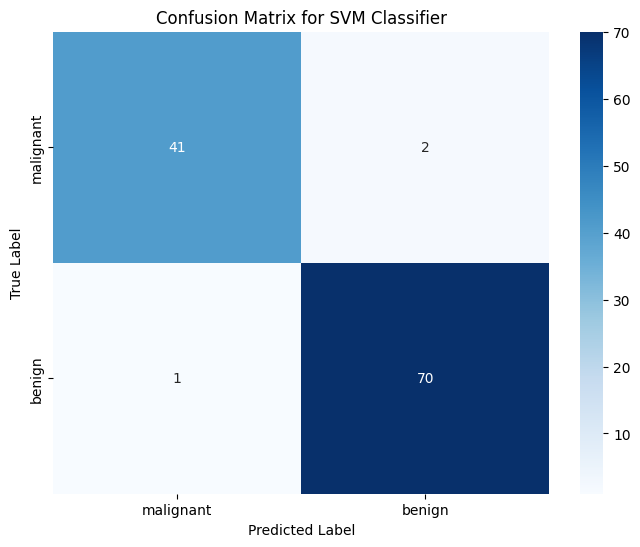

In [13]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names for labels
class_names = cancer.target_names

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for SVM Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()